#  Identification of spatial patterns in the MEC



In [ ]:
import pandas as pd
import numpy as np

path = "matriculaciones_departamentos_distritos_20260120.csv"
df = pd.read_csv(path)

#  Standardize names in case of variations in uppercase and lowercase letters
df["nombre_zona"] = df["nombre_zona"].astype(str).str.strip()
df["sector_o_tipo_gestion"] = df["sector_o_tipo_gestion"].astype(str).str.strip()

df["h"] = pd.to_numeric(df["cantidad_matriculados_hombre"], errors="coerce").fillna(0)
df["m"] = pd.to_numeric(df["cantidad_matriculados_mujer"], errors="coerce").fillna(0)
df["total"] = df["h"] + df["m"]

df.head(), df.shape


(   anio  codigo_departamento nombre_departamento  codigo_distrito  \
 0  2023                   17       Alto Paraguay                4   
 1  2023                   17       Alto Paraguay                4   
 2  2023                   17       Alto Paraguay                4   
 3  2023                   17       Alto Paraguay                5   
 4  2023                   17       Alto Paraguay                5   
 
    nombre_distrito  codigo_zona nombre_zona sector_o_tipo_gestion  \
 0      Bahía Negra            1      Urbana               Oficial   
 1      Bahía Negra            2       Rural               Privado   
 2      Bahía Negra            2       Rural               Oficial   
 3  Carmelo Peralta            2       Rural               Oficial   
 4  Carmelo Peralta            1      Urbana               Oficial   
 
    anho_cod_geo  cantidad_matriculados_hombre  cantidad_matriculados_mujer  \
 0           NaN                           244                          205  

## 1.Data loading and initial setup

In this section, the source data is loaded, relevant categorical column names are standardized, and auxiliary variables for student ID by gender are created.

In [ ]:
from scipy.stats import entropy

group_cols = ["codigo_departamento","nombre_departamento","codigo_distrito","nombre_distrito"]

def entropia_contexto(sub):
    # Enrollment by (area, sector)
    combos = sub.groupby(["nombre_zona","sector_o_tipo_gestion"])["total"].sum()
    if combos.sum() == 0:
        return 0.0
    p = (combos / combos.sum()).values
    return float(entropy(p, base=2))

rows = []
for keys, sub in df.groupby(group_cols):
    total = sub["total"].sum()
    h = sub["h"].sum()
    m = sub["m"].sum()

    # Smoothing for numerical stability
    pct_mujeres = (m + 0.5) / (total + 1.0) if total > 0 else np.nan
    ratio_h_m = (h + 0.5) / (m + 0.5)

    urbana = sub.loc[sub["nombre_zona"].str.lower()=="urbana", "total"].sum()
    privado = sub.loc[sub["sector_o_tipo_gestion"].str.lower()=="privado", "total"].sum()

    rows.append((*keys,
                 total,
                 pct_mujeres,
                 ratio_h_m,
                 (urbana/total if total>0 else 0.0),
                 (privado/total if total>0 else 0.0),
                 entropia_contexto(sub)))

territ = pd.DataFrame(rows, columns=group_cols + [
    "matricula_total","pct_mujeres","ratio_h_m","share_urbana","share_privado","entropia_contexto"
])

territ.describe(include="all")


,codigo_departamento,nombre_departamento,codigo_distrito,nombre_distrito,matricula_total,pct_mujeres,ratio_h_m,share_urbana,share_privado,entropia_contexto
count,263.000000,263,263.000000,263,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000
unique,NaN,18,NaN,261,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Itapúa,NaN,Bella Vista,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,30,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
mean,7.692015,NaN,9.806084,NaN,5888.034221,0.494535,1.023895,0.486096,0.036201,1.123780
std,4.327285,NaN,6.399281,NaN,12347.822527,0.014759,0.060403,0.267556,0.061842,0.441236
min,0.000000,NaN,0.000000,NaN,144.000000,0.450000,0.796853,0.000000,0.000000,0.000000
25%,4.000000,NaN,5.000000,NaN,1201.000000,0.486826,0.991791,0.286710,0.000000,0.885088
50%,7.000000,NaN,9.000000,NaN,2375.000000,0.494887,1.020662,0.476080,0.006740,1.061676
75%,11.000000,NaN,14.000000,NaN,5269.000000,0.502061,1.054121,0.679697,0.046088,1.456074


## 2. Construction of Territorial Variables

Data at the district level are aggregated, and the territorial variables used in the analysis are calculated:

- `matricula_total`
- `pct_mujeres`
- `share_urbana`
- `share_privado`
- `entropia_contexto`

In [ ]:
!pip -q install umap-learn

from sklearn.preprocessing import StandardScaler
import umap

features = ["matricula_total","pct_mujeres","share_urbana","share_privado","entropia_contexto"]

X = territ[features].replace([np.inf,-np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

Xs = StandardScaler().fit_transform(X)

umap_model = umap.UMAP(
    n_neighbors=15,     # neighborhood
    min_dist=0.05,      # visual compactness
    n_components=2,
    random_state=42
)
emb = umap_model.fit_transform(Xs)

territ["u1"] = emb[:,0]
territ["u2"] = emb[:,1]
territ.head()


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,codigo_departamento,nombre_departamento,codigo_distrito,nombre_distrito,matricula_total,pct_mujeres,ratio_h_m,share_urbana,share_privado,entropia_contexto,u1,u2
0,0,Capital,0,Asunción,131222,0.501402,0.994407,1.000000,0.309331,1.544217,9.142024,9.964774
1,1,Concepción,1,Concepción,21216,0.497078,1.011757,0.877262,0.042704,1.637785,8.251746,9.879683
2,1,Concepción,2,Belén,3364,0.473848,1.110379,0.225030,0.000000,0.769246,0.534139,6.214655
3,1,Concepción,3,Horqueta,10989,0.499227,1.003099,0.393211,0.009919,1.486216,6.120665,7.870396
4,1,Concepción,4,Loreto,4028,0.487342,1.051948,0.445879,0.016634,1.093993,2.808959,6.477300


## 3. Nonlinear dimensionality reduction using UMAP
The analytical variables are standardized, and a two-dimensional UMAP projection is generated.

In [ ]:
!pip -q install hdbscan

import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=12,
    min_samples=8,          # higher = more noise points
    metric="euclidean"
)

labels = clusterer.fit_predict(emb)
territ["cluster"] = labels
territ["prob_cluster"] = clusterer.probabilities_

territ["cluster"].value_counts().sort_index()


,count
cluster,
-1,37
0,21
1,52
2,30
3,27
4,72
5,24


## 4. Density-based clustering with HDBSCAN

HDBSCAN is run on the UMAP representation to identify clusters and noise.

In [ ]:
from sklearn.neighbors import LocalOutlierFactor


# Option 1 (recommended): LOF in the original scaled space (interpretable by variables)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)  # 5% outliers (ajustable)
pred = lof.fit_predict(Xs)
score = -lof.negative_outlier_factor_  # higher = more atypical

territ["lof_outlier"] = (pred == -1).astype(int)
territ["lof_score"] = score

territ.sort_values("lof_score", ascending=False).head(15)[
    ["nombre_departamento","nombre_distrito","cluster","lof_score","matricula_total","share_urbana","share_privado","pct_mujeres"]
]


,nombre_departamento,nombre_distrito,cluster,lof_score,matricula_total,share_urbana,share_privado,pct_mujeres
0,Capital,Asunción,0,3.931371,131222,1.000000,0.309331,0.501402
166,Alto Paraná,Ciudad del Este,0,2.553032,90591,0.999746,0.198607,0.517645
253,Presidente Hayes,Campo Aceval,4,2.446381,1230,0.000000,0.385366,0.500812
14,Concepción,Itacuá,1,2.247583,688,0.000000,0.000000,0.527576
74,Guairá,Tebicuary,5,2.080992,627,0.727273,0.000000,0.556529
36,San Pedro,San José del Rosario,1,1.949975,862,0.000000,0.112529,0.488413
257,Boquerón,Loma Plata,4,1.882734,6043,0.467979,0.340063,0.498097
228,Amambay,Cerro Corá,1,1.833956,2333,0.000000,0.000000,0.515638
146,Misiones,Villa Florida,3,1.787631,786,1.000000,0.000000,0.482211
5,Concepción,San Carlos del Apa,-1,1.777147,185,1.000000,0.000000,0.497312


## 5. Detection of local anomalies using LOF

The Local Outlier Factor is applied to the original scaled space to identify outliers.

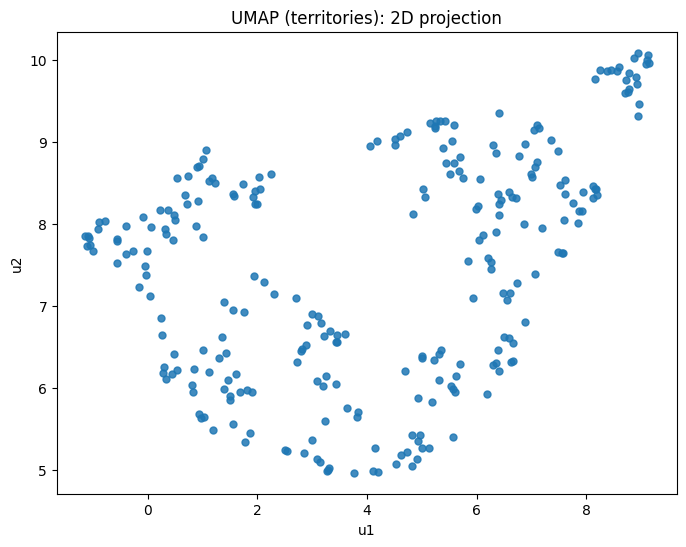

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(territ["u1"], territ["u2"], s=25, alpha=0.85)
plt.title("UMAP (territories): 2D projection")
plt.xlabel("u1"); plt.ylabel("u2")
plt.show()


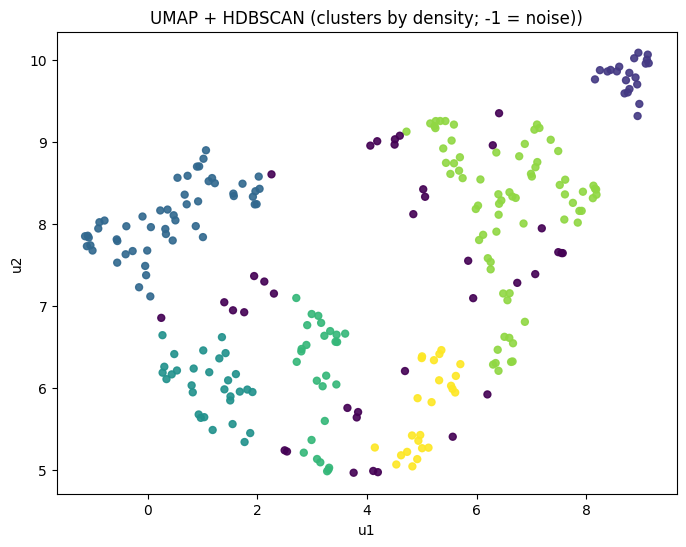

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(territ["u1"], territ["u2"], c=territ["cluster"], s=25, alpha=0.9)
plt.title("UMAP + HDBSCAN (clusters by density; -1 = noise))")
plt.xlabel("u1"); plt.ylabel("u2")
plt.show()


## 6.  Display of Results
The main figures from the analysis are presented: the UMAP projection and the cluster-colored UMAP.

In [ ]:
perfil = territ[features + ["cluster"]].groupby("cluster").agg(["mean","median","count"])
perfil


matricula_total                pct_mujeres                  \
                   mean   median count        mean    median count   
cluster                                                              
-1          2671.243243   1679.0    37    0.494065  0.493750    37   
 0         35904.476190  27466.0    21    0.496632  0.497078    21   
 1          3557.750000   3423.0    52    0.496197  0.495046    52   
 2          1840.066667   1220.5    30    0.471720  0.474960    30   
 3          1832.370370   1309.0    27    0.491204  0.491759    27   
 4          5124.944444   3306.0    72    0.496831  0.496414    72   
 5          1543.666667   1119.5    24    0.515203  0.512819    24   

        share_urbana                 share_privado                  \
                mean    median count          mean    median count   
cluster                                                              
-1          0.523653  0.519026    37      0.034870  0.019737    37   
 0          0.917771  0.995753    21      0.137470  0.119210    21   
 1          0.155177  0.184000    52      0.013101  0.000000    52   
 2          0.334070  0.316315    30      0.001865  0.000000    30   
 3          0.579749  0.527884    27      0.001763  0.000000    27   
 4          0.571909  0.566448    72      0.061379  0.037527    72   
 5          0.594705  0.573606    24      0.005820  0.000000    24   

        entropia_contexto                  
                     mean    median count  
cluster                                    
-1               1.086409  1.156813    37  
 0               1.301655  1.375393    21  
 1               0.700829  0.755742    52  
 2               0.891464  0.921499    30  
 3               0.921514  0.993482    27  
 4               1.612966  1.553965    72  
 5               0.992533  0.988347    24

In [ ]:
X.describe()

,matricula_total,pct_mujeres,share_urbana,share_privado,entropia_contexto
count,263.000000,263.000000,263.000000,263.000000,263.000000
mean,5888.034221,0.494535,0.486096,0.036201,1.123780
std,12347.822527,0.014759,0.267556,0.061842,0.441236
min,144.000000,0.450000,0.000000,0.000000,0.000000
25%,1201.000000,0.486826,0.286710,0.000000,0.885088
50%,2375.000000,0.494887,0.476080,0.006740,1.061676
75%,5269.000000,0.502061,0.679697,0.046088,1.456074
max,131222.000000,0.556529,1.000000,0.385366,2.170644


In [ ]:
df.describe()


,anio,codigo_departamento,codigo_distrito,codigo_zona,anho_cod_geo,cantidad_matriculados_hombre,cantidad_matriculados_mujer,h,m,total
count,844.0,844.000000,844.000000,844.000000,0.0,844.000000,844.000000,844.000000,844.000000,844.000000
mean,2023.0,7.867299,9.356635,1.428910,NaN,922.819905,911.958531,922.819905,911.958531,1834.778436
std,0.0,4.346654,6.497892,0.495214,NaN,2459.178483,2468.168744,2459.178483,2468.168744,4925.666279
min,2023.0,0.000000,0.000000,1.000000,NaN,0.000000,2.000000,0.000000,2.000000,4.000000
25%,2023.0,4.000000,4.000000,1.000000,NaN,103.000000,107.000000,103.000000,107.000000,214.500000
50%,2023.0,7.000000,8.000000,1.000000,NaN,297.000000,297.000000,297.000000,297.000000,603.500000
75%,2023.0,11.000000,14.000000,2.000000,NaN,769.750000,754.500000,769.750000,754.500000,1521.250000
max,2023.0,17.000000,30.000000,2.000000,NaN,33446.000000,35997.000000,33446.000000,35997.000000,69443.000000


In [ ]:
top_out = territ.sort_values("lof_score", ascending=False).head(10)
top_out[["nombre_departamento","nombre_distrito","cluster","lof_score"] + features]


,nombre_departamento,nombre_distrito,cluster,lof_score,matricula_total,pct_mujeres,share_urbana,share_privado,entropia_contexto
0,Capital,Asunción,0,3.931371,131222,0.501402,1.000000,0.309331,1.544217
166,Alto Paraná,Ciudad del Este,0,2.553032,90591,0.517645,0.999746,0.198607,0.928052
253,Presidente Hayes,Campo Aceval,4,2.446381,1230,0.500812,0.000000,0.385366,1.070098
14,Concepción,Itacuá,1,2.247583,688,0.527576,0.000000,0.000000,0.000000
74,Guairá,Tebicuary,5,2.080992,627,0.556529,0.727273,0.000000,0.845351
36,San Pedro,San José del Rosario,1,1.949975,862,0.488413,0.000000,0.112529,0.507497
257,Boquerón,Loma Plata,4,1.882734,6043,0.498097,0.467979,0.340063,2.092898
228,Amambay,Cerro Corá,1,1.833956,2333,0.515638,0.000000,0.000000,0.000000
146,Misiones,Villa Florida,3,1.787631,786,0.482211,1.000000,0.000000,0.000000
5,Concepción,San Carlos del Apa,-1,1.777147,185,0.497312,1.000000,0.000000,0.000000


In [ ]:
df.describe()

,anio,codigo_departamento,codigo_distrito,codigo_zona,anho_cod_geo,cantidad_matriculados_hombre,cantidad_matriculados_mujer,h,m,total
count,844.0,844.000000,844.000000,844.000000,0.0,844.000000,844.000000,844.000000,844.000000,844.000000
mean,2023.0,7.867299,9.356635,1.428910,NaN,922.819905,911.958531,922.819905,911.958531,1834.778436
std,0.0,4.346654,6.497892,0.495214,NaN,2459.178483,2468.168744,2459.178483,2468.168744,4925.666279
min,2023.0,0.000000,0.000000,1.000000,NaN,0.000000,2.000000,0.000000,2.000000,4.000000
25%,2023.0,4.000000,4.000000,1.000000,NaN,103.000000,107.000000,103.000000,107.000000,214.500000
50%,2023.0,7.000000,8.000000,1.000000,NaN,297.000000,297.000000,297.000000,297.000000,603.500000
75%,2023.0,11.000000,14.000000,2.000000,NaN,769.750000,754.500000,769.750000,754.500000,1521.250000
max,2023.0,17.000000,30.000000,2.000000,NaN,33446.000000,35997.000000,33446.000000,35997.000000,69443.000000


## 7. Cluster Profiles and Atypical Territories

Aggregated profiles by cluster are summarized, and the territories with the highest anomaly scores are listed.

In [ ]:
territ.to_csv("paper2_territorial_resultados.csv", index=False)
perfil.to_csv("paper2_territorial_perfil_clusters.csv")
top_out.to_csv("paper2_territorial_top_outliers.csv", index=False)

print("Listo: CSVs generados.")


Listo: CSVs generados.


In [ ]:
import zipfile
import os

# Make sure the files are saved
territ.to_csv("paper2_territorial_resultados.csv", index=False)
perfil.to_csv("paper2_territorial_perfil_clusters.csv")
top_out.to_csv("paper2_territorial_top_outliers.csv", index=False)

# Also available in Excel format (easier to review)
with pd.ExcelWriter("paper2_territorial_resultados.xlsx") as writer:
    territ.to_excel(writer, sheet_name="Resultados_completos", index=False)
    perfil.to_excel(writer, sheet_name="Perfil_clusters")
    top_out.to_excel(writer, sheet_name="Top_outliers", index=False)

# Create ZIP
zip_filename = "Paper2_Analisis_Territorial_UMAP_HDBSCAN_LOF.zip"

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    zipf.write("paper2_territorial_resultados.csv")
    zipf.write("paper2_territorial_perfil_clusters.csv")
    zipf.write("paper2_territorial_top_outliers.csv")
    zipf.write("paper2_territorial_resultados.xlsx")

print("ZIP generado:", zip_filename)


ZIP generado: Paper2_Analisis_Territorial_UMAP_HDBSCAN_LOF.zip


In [ ]:
from google.colab import files
files.download("Paper2_Analisis_Territorial_UMAP_HDBSCAN_LOF.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Exporting Results

CSV, Excel, and ZIP files containing the analysis results are exported.

In [ ]:
print("Clusters:")
print(territ['cluster'].value_counts().sort_index())

print("\nNoise level:")
print((territ['cluster'] == -1).sum())

print("\n Anomalies LOF:")
print(territ['lof_outlier'].sum())

Clusters:
cluster
-1    37
 0    21
 1    52
 2    30
 3    27
 4    72
 5    24
Name: count, dtype: int64

Noise level:
37

 Anomalies LOF:
14


In [ ]:
territ.groupby("cluster")[[
    "matricula_total",
    "pct_mujeres",
    "share_urbana",
    "share_privado",
    "entropia_contexto"
]].mean().round(3)

,matricula_total,pct_mujeres,share_urbana,share_privado,entropia_contexto
cluster,,,,,
-1,2070.680,0.488,0.509,0.028,1.009
0,35904.476,0.497,0.918,0.137,1.302
1,1781.781,0.473,0.334,0.002,0.893
2,3557.750,0.496,0.155,0.013,0.701
3,1826.769,0.492,0.567,0.002,0.941
4,4236.224,0.502,0.583,0.048,1.435


In [ ]:
df.describe()


,anio,codigo_departamento,codigo_distrito,codigo_zona,anho_cod_geo,cantidad_matriculados_hombre,cantidad_matriculados_mujer,h,m,total
count,844.0,844.000000,844.000000,844.000000,0.0,844.000000,844.000000,844.000000,844.000000,844.000000
mean,2023.0,7.867299,9.356635,1.428910,NaN,922.819905,911.958531,922.819905,911.958531,1834.778436
std,0.0,4.346654,6.497892,0.495214,NaN,2459.178483,2468.168744,2459.178483,2468.168744,4925.666279
min,2023.0,0.000000,0.000000,1.000000,NaN,0.000000,2.000000,0.000000,2.000000,4.000000
25%,2023.0,4.000000,4.000000,1.000000,NaN,103.000000,107.000000,103.000000,107.000000,214.500000
50%,2023.0,7.000000,8.000000,1.000000,NaN,297.000000,297.000000,297.000000,297.000000,603.500000
75%,2023.0,11.000000,14.000000,2.000000,NaN,769.750000,754.500000,769.750000,754.500000,1521.250000
max,2023.0,17.000000,30.000000,2.000000,NaN,33446.000000,35997.000000,33446.000000,35997.000000,69443.000000
